In [9]:
# Upload the disney hotstar dataset to Colab
from google.colab import files
uploaded = files.upload()


Saving disney_plus_titles.csv to disney_plus_titles (1).csv


In [17]:
import pandas as pd

# Replace with exact filename if needed
df = pd.read_csv("/content/disney_plus_titles (1).csv", encoding='latin-1') # Changed the encoding to 'latin-1'

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Apply the Seaborn style
sns.set_theme(style="darkgrid")  # Seaborn provides various styles, e.g., 'darkgrid', 'whitegrid', 'dark', 'white', 'ticks'

# The 'Set2' palette is already the default in Seaborn
# If you want to be explicit:
sns.set_palette('Set2')

import warnings
warnings.filterwarnings('ignore')

In [19]:
# 📌 STEP 2: Load the CSV
df = pd.read_csv("/content/disney_plus_titles (1).csv", encoding='latin-1')

# 📌 STEP 3: Basic Info
print("Dataset Shape:", df.shape)
print("\nColumns:\n", df.columns)
df.info()
df.head()


Dataset Shape: (1450, 12)

Columns:
 Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1450 entries, 0 to 1449
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       1450 non-null   object
 1   type          1450 non-null   object
 2   title         1450 non-null   object
 3   director      977 non-null    object
 4   cast          1260 non-null   object
 5   country       1231 non-null   object
 6   date_added    1447 non-null   object
 7   release_year  1450 non-null   int64 
 8   rating        1447 non-null   object
 9   duration      1450 non-null   object
 10  listed_in     1450 non-null   object
 11  description   1450 non-null   object
dtypes: int64(1), object(11)
memory usage: 136.1+ KB


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Duck the Halls: A Mickey Mouse Christmas Special,"Alonso Ramirez Ramos, Dave Wasson","Chris Diamantopoulos, Tony Anselmo, Tress MacN...",NaN,"November 26, 2021",2016,TV-G,23 min,"Animation, Family",Join Mickey and the gang as they duck the halls!
1,s2,Movie,Ernest Saves Christmas,John Cherry,"Jim Varney, Noelle Parker, Douglas Seale",NaN,"November 26, 2021",1988,PG,91 min,Comedy,Santa Claus passes his magic bag to a new St. ...
2,s3,Movie,Ice Age: A Mammoth Christmas,Karen Disher,"Raymond Albert Romano, John Leguizamo, Denis L...",United States,"November 26, 2021",2011,TV-G,23 min,"Animation, Comedy, Family",Sid the Sloth is on Santa's naughty list.
3,s4,Movie,The Queen Family Singalong,Hamish Hamilton,"Darren Criss, Adam Lambert, Derek Hough, Alexa...",NaN,"November 26, 2021",2021,TV-PG,41 min,Musical,"This is real life, not just fantasy!"
4,s5,TV Show,The Beatles: Get Back,NaN,"John Lennon, Paul McCartney, George Harrison, ...",NaN,"November 25, 2021",2021,NaN,1 Season,"Docuseries, Historical, Music",A three-part documentary from Peter Jackson ca...


In [20]:
# Check for missing values
print("\nMissing Values:\n", df.isnull().sum())

# Drop missing rows (optional)
df.dropna(inplace=True)

# Convert date column if exists
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')



Missing Values:
 show_id           0
type              0
title             0
director        473
cast            190
country         219
date_added        3
release_year      0
rating            3
duration          0
listed_in         0
description       0
dtype: int64


In [23]:
# Drop duplicates
df.drop_duplicates(inplace=True)

# Fill missing values
df['country'] = df['country'].fillna('Unknown')
df['director'] = df['director'].fillna('Not Specified')
df['cast'] = df['cast'].fillna('Not Specified')

df['director'].fillna('Not Specified', inplace=True)
df['cast'].fillna('Not Specified', inplace=True)
df.dropna(subset=['date_added'], inplace=True)

# Convert 'date_added' to datetime
# Strip extra spaces and convert to datetime
df['date_added'] = pd.to_datetime(df['date_added'].str.strip(), format='mixed')

df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month


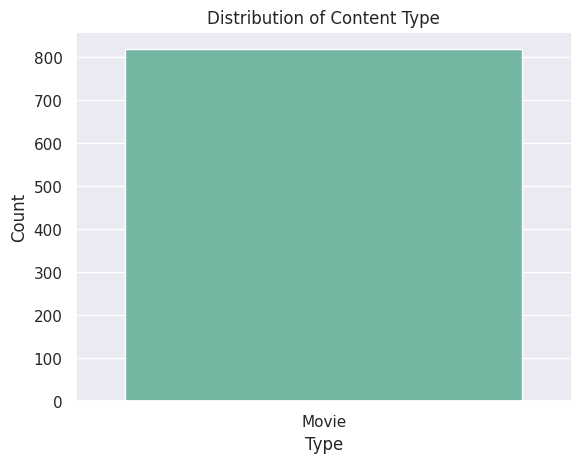

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x='type', palette='Set2')
plt.title('Distribution of Content Type')
plt.xlabel('Type')
plt.ylabel('Count')
plt.show()


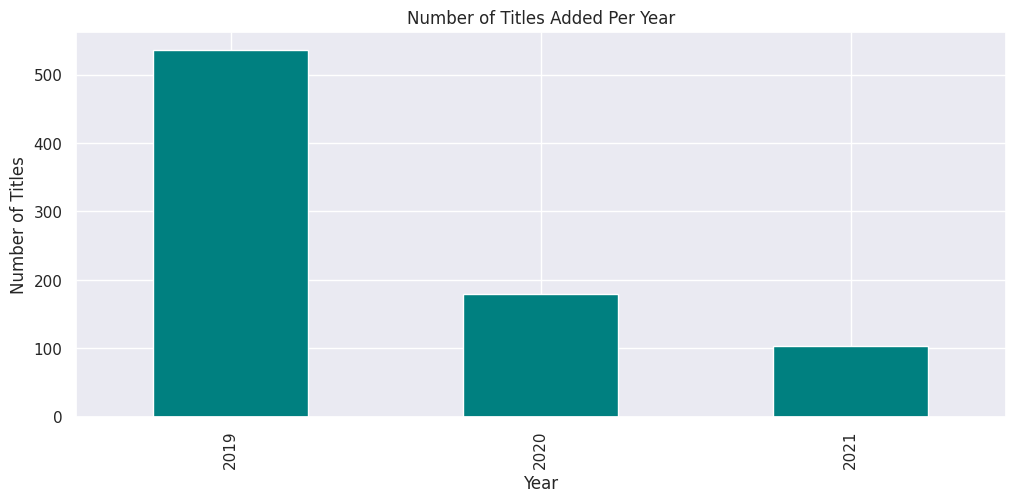

In [25]:
df['year_added'].value_counts().sort_index().plot(kind='bar', figsize=(12, 5), color='teal')
plt.title('Number of Titles Added Per Year')
plt.xlabel('Year')
plt.ylabel('Number of Titles')
plt.grid(True)
plt.show()


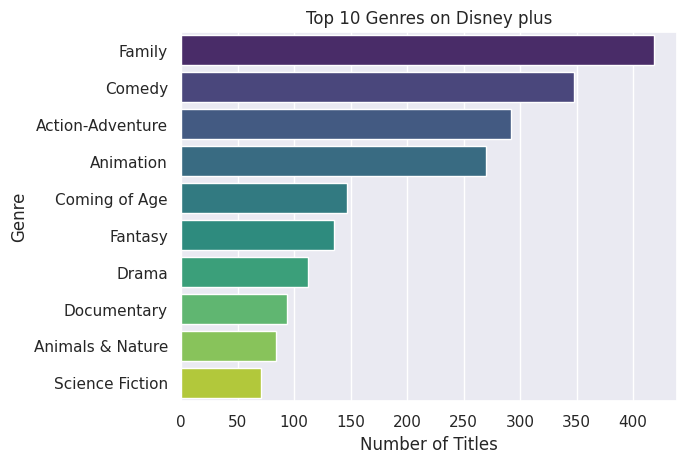

In [29]:
from collections import Counter

genre_list = df['listed_in'].str.split(', ')
flat_genres = [genre for sublist in genre_list.dropna() for genre in sublist]
genre_counts = Counter(flat_genres).most_common(10)

# Convert to DataFrame
genre_df = pd.DataFrame(genre_counts, columns=['Genre', 'Count'])
sns.barplot(data=genre_df, y='Genre', x='Count', palette='viridis')
plt.title('Top 10 Genres on Disney plus')
plt.xlabel('Number of Titles')
plt.ylabel('Genre')
plt.show()


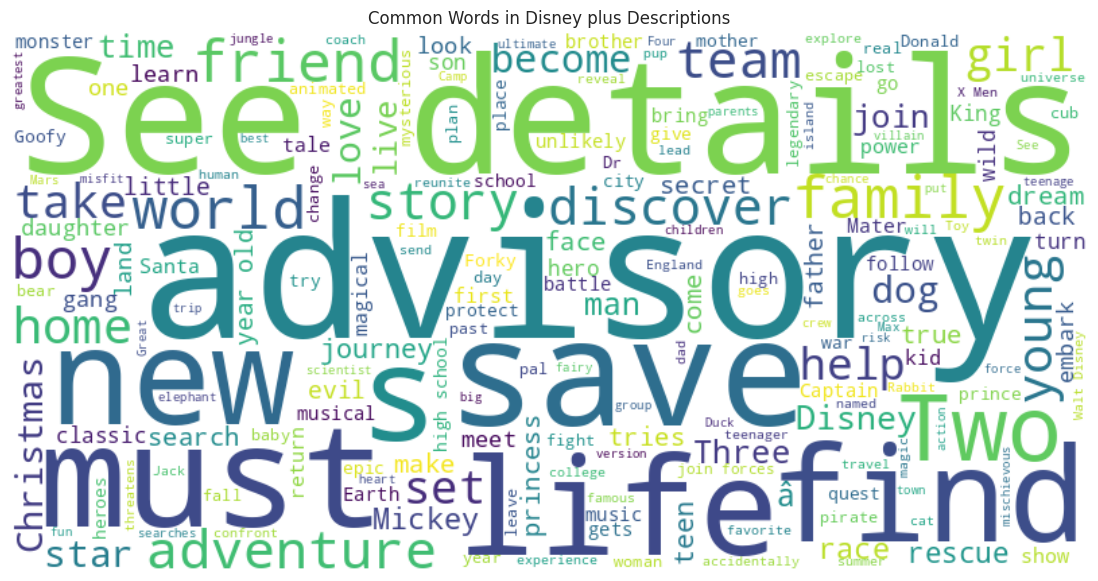

In [31]:
from wordcloud import WordCloud

text = ' '.join(df['description'].dropna())
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Common Words in Disney plus Descriptions')
plt.show()


In [32]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

# Genre clustering
df['listed_in'] = df['listed_in'].fillna('')
tfidf = TfidfVectorizer(stop_words='english')
X = tfidf.fit_transform(df['listed_in'])

kmeans = KMeans(n_clusters=3, random_state=42)
df['genre_cluster'] = kmeans.fit_predict(X)

# Display cluster distribution
df['genre_cluster'].value_counts()

,count
genre_cluster,
1,429
2,242
0,147
